# Анализ русскоязычного датасета тональности и тематическое моделирование

**Датасет:** [`MonoHime/ru_sentiment_dataset`](https://huggingface.co/datasets/MonoHime/ru_sentiment_dataset/tree/main).

В notebook выполнены:

- скачивание и загрузка данных с HuggingFace;
- разведывательный анализ текстов;
- тематическое моделирование и визуализация тем;
- обучение классификатора тональности;
- оценка качества и скорости инференса на CPU и GPU, если CUDA доступна;
- факультативная CPU-оптимизация линейного классификатора через ONNX Runtime после TF-IDF-векторизации.

Метки датасета: `0` — neutral, `1` — positive, `2` — negative.

## 0. Подготовка окружения

Notebook рассчитан на обычное Python-окружение с `pandas`, `scikit-learn`, `matplotlib`, `seaborn` и опционально `torch`/`onnxruntime`. Для воспроизводимого CPU-запуска используется ограничение обучающей выборки; для полного эксперимента можно поставить `MAX_ROWS_TRAIN = None`, но такой прогон занимает заметно больше времени.

In [1]:
# Если окружение пустое, раскомментируйте установку зависимостей.
# %pip install -q pandas numpy scikit-learn matplotlib seaborn requests tqdm torch wordcloud
# Для факультативной ONNX-оптимизации:
# %pip install -q skl2onnx onnxruntime

from __future__ import annotations

import gc
import os
import re
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from IPython.display import display
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.0)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Поддерживаются два варианта локального хранения:
# 1) data/train.csv и data/valid.csv;
# 2) ru_sentiment_dataset/train.csv и ru_sentiment_dataset/valid.csv после git clone.
DATA_DIR = Path("data")
CLONED_DATA_DIR = Path("ru_sentiment_dataset")
if not (DATA_DIR / "train.csv").exists() and (CLONED_DATA_DIR / "train.csv").exists():
    DATA_DIR = CLONED_DATA_DIR
else:
    DATA_DIR.mkdir(exist_ok=True)

# Ограничитель нужен, чтобы notebook стабильно выполнялся на CPU за разумное время.
# Для полного эксперимента можно поставить None и перезапустить notebook.
MAX_ROWS_TRAIN = 80_000
MAX_ROWS_VALID = None
TOPIC_SAMPLE_SIZE = 40_000
N_TOPICS = 8

LABEL_NAMES = {0: "neutral", 1: "positive", 2: "negative"}
LABEL_ORDER = [0, 1, 2]

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_colwidth", 160)

C:\Users\fburl\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Скачивание датасета

Используются оригинальные CSV-файлы из репозитория HuggingFace. В датасете уже есть `train.csv` и `valid.csv`; далее из обучающей части дополнительно выделяется validation, а исходный `valid.csv` используется как отложенный test, чтобы получить честную финальную оценку.

In [2]:
HF_BASE = "https://huggingface.co/datasets/MonoHime/ru_sentiment_dataset/resolve/main"
FILES = {
    "train": DATA_DIR / "train.csv",
    "test": DATA_DIR / "valid.csv",
}


def download_file(url: str, dst: Path, chunk_size: int = 1 << 20) -> None:
    """Download a file with progress and keep existing files intact."""
    if dst.exists() and dst.stat().st_size > 0:
        print(f"Файл уже есть: {dst} ({dst.stat().st_size / 1024**2:.1f} MB)")
        return

    with requests.get(url, stream=True, timeout=60) as response:
        response.raise_for_status()
        total = int(response.headers.get("content-length", 0))
        with dst.open("wb") as f, tqdm(total=total, unit="B", unit_scale=True, desc=dst.name) as pbar:
            for chunk in response.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))


for split_name, path in FILES.items():
    download_file(f"{HF_BASE}/{path.name}", path)

Файл уже есть: ru_sentiment_dataset\train.csv (262.8 MB)
Файл уже есть: ru_sentiment_dataset\valid.csv (30.5 MB)


In [3]:
def load_split(path: Path, nrows: int | None = None) -> pd.DataFrame:
    df = pd.read_csv(path, nrows=nrows)
    df = df.rename(columns={"Unnamed: 0": "source_id"})
    df = df[["text", "sentiment"]].copy()
    df["text"] = df["text"].astype(str)
    df["sentiment"] = df["sentiment"].astype(int)
    return df


raw_train = load_split(FILES["train"], MAX_ROWS_TRAIN)
raw_test = load_split(FILES["test"], MAX_ROWS_VALID)

print(f"train: {raw_train.shape}")
print(f"test : {raw_test.shape}")
display(raw_train.head())

train: (80000, 2)
test : (21098, 2)


,text,sentiment
0,".с.,и спросил его: о Посланник Аллаха!Ты порицаешь что-то из слушания? Он ответил: я не порицаю ничего из него,но передай им,чтобы они открывали свои собр...",1
1,"Роднее всех родных Попала я в ГКБ №8 еще в декабре 2002 г. Ехать в больницу очень боялась, но делать нечего, рожать надо. О ГКБ № 8 слышала много хорошего. ...",1
2,"Непорядочное отношение к своим работникам Работаю в сети Доктор Столетов Центр. В моем трудовом договоре прописано, что работад. оплачивает обучение по серт...",2
3,"). Отсутствуют нормативы, Госты и прочее, что позволило бы отличить хорошие правильные наркотики от плохих неправильных . У алкоголя и табака они вырабат...",1
4,"У меня машина в руках 5 лет и это первая моя машина и не могу с ней никак расстаться! Ни разу меня не подвела, заводилась после ночи на улице зим...",1


## 2. EDA: первичный анализ данных

In [4]:
eda = pd.concat(
    [raw_train.assign(split="train"), raw_test.assign(split="test")],
    ignore_index=True,
)

eda["label"] = eda["sentiment"].map(LABEL_NAMES)
eda["char_len"] = eda["text"].str.len()
eda["word_len"] = eda["text"].str.split().str.len()

summary = pd.DataFrame(
    {
        "rows": eda.groupby("split").size(),
        "missing_text": eda.groupby("split")["text"].apply(lambda x: x.isna().sum()),
        "duplicates": eda.groupby("split")["text"].apply(lambda x: x.duplicated().sum()),
        "median_chars": eda.groupby("split")["char_len"].median(),
        "p95_chars": eda.groupby("split")["char_len"].quantile(0.95),
        "median_words": eda.groupby("split")["word_len"].median(),
    }
)
display(summary)

display(
    eda.groupby(["split", "label"])
    .size()
    .rename("count")
    .reset_index()
    .assign(share=lambda x: x["count"] / x.groupby("split")["count"].transform("sum"))
)

,rows,missing_text,duplicates,median_chars,p95_chars,median_words
split,,,,,,
test,21098,0,137,511.0,2238.45,78.0
train,80000,0,1870,503.0,2179.00,76.0


,split,label,count,share
0,test,negative,5512,0.261257
1,test,neutral,5560,0.263532
2,test,positive,10026,0.475211
3,train,negative,21224,0.265300
4,train,neutral,20567,0.257088
5,train,positive,38209,0.477612


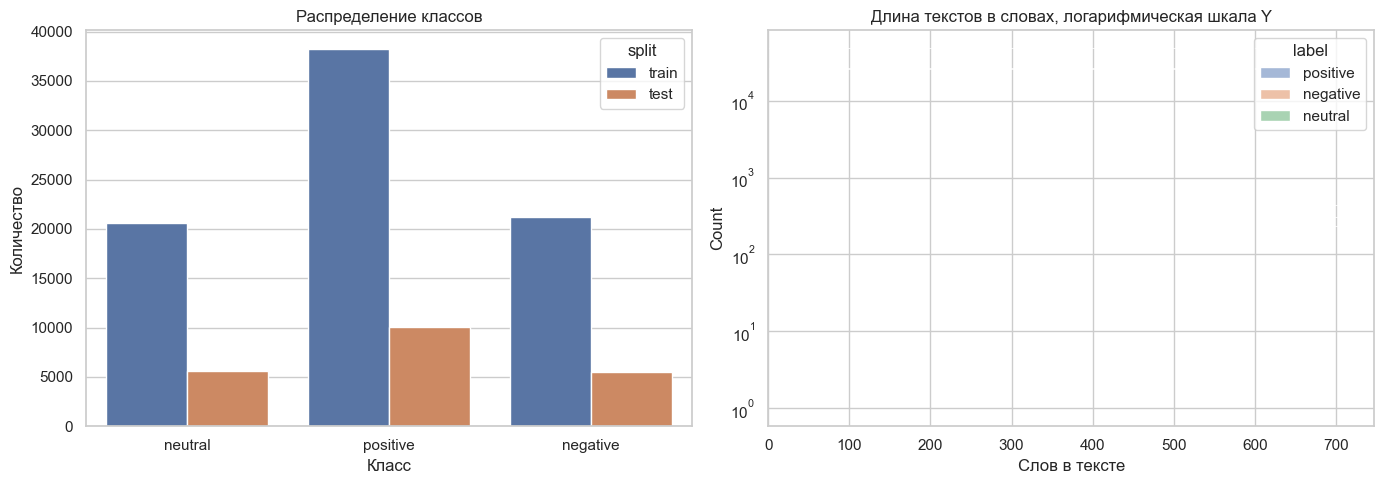

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=eda, x="label", hue="split", order=[LABEL_NAMES[i] for i in LABEL_ORDER], ax=axes[0])
axes[0].set_title("Распределение классов")
axes[0].set_xlabel("Класс")
axes[0].set_ylabel("Количество")

sns.histplot(data=eda, x="word_len", hue="label", bins=60, log_scale=(False, True), ax=axes[1])
axes[1].set_xlim(0, eda["word_len"].quantile(0.99))
axes[1].set_title("Длина текстов в словах, логарифмическая шкала Y")
axes[1].set_xlabel("Слов в тексте")
plt.tight_layout()
plt.show()

In [6]:
for label_id, label_name in LABEL_NAMES.items():
    print("\n" + "=" * 100)
    print(f"Примеры класса {label_id}: {label_name}")
    display(
        raw_train.loc[raw_train["sentiment"].eq(label_id), ["text", "sentiment"]]
        .sample(3, random_state=RANDOM_STATE)
    )


Примеры класса 0: neutral


,text,sentiment
18704,"Минск, 28 Октября 2016, 21:56 — REGNUM По итогам состоявшегося 28 октября в Минске заседания Совета глав правительств СНГ подписан пакет документов о...",0
21884,"там за такое посадят БЛЯСТАТЕЛЬНЫЙ ТОВАРИЩ АДОБРЯЭ!!!КСТАТИ В КНДР ЗА ПРОН СМЕРТНАЯ КАЗНЬ...ДАЖЕ ЗА ПРОСМОТР! Это Японцы Наталья,вообще-то иероглифы япон...",0
4153,"Отель находится около метро Рижская. До центра недалеко. На ресепшн заселение быстро, дружелюбно.Ремонт новый, в номерах все есть что нужно: удобная кровать...",0



Примеры класса 1: positive


,text,sentiment
11848,"Хочу поблагодарить весь персонал детской хирургии Неделю назад лежали в ДХО с ребенком. Отношение персонала отличное, все понравилось! Хочу сказать большое ...",1
72051,"чень грамотно и всё по полочкам:-))) Спасибо!!! Даша, а какой расклад по элитам? Есть ли про-Ататюрковские? ???°, ????N??µN??µN????? N? ????N? N??°??...??...",1
60584,"Благодарность профессору Василию Викторовичу Николаеву Я и моя семья благодарим Бога за то, что наша доченька Дашенька попала в надежные руки профессора, де...",1



Примеры класса 2: negative


,text,sentiment
66525,всем сюда всем говорю лучшее заведение !!! еда просто супер !! офицанты могут объяснить из чего состоят блюда !!!,2
58284,"Неквалифицированные врачи в реанимации Врачи ужасные в реанимации для новорожденных, то прокуренным ртом стоит возле кювеза отвечает на вопросы сквозь свои ...",2
23599,просто не либераст бездомный.,2


**Выводы EDA.** Датасет крупный, тексты русскоязычные и сильно различаются по длине: встречаются короткие реплики и длинные отзывы/новости. Классы обычно несбалансированы, поэтому одной accuracy недостаточно: модель может выглядеть хорошо за счёт доминирующего класса. Для обучения важно стратифицировать разбиение и использовать метрику, учитывающую каждый класс.

## 3. Предобработка текстов

Для тем и базового классификатора используется лёгкая нормализация: нижний регистр, замена `ё` на `е`, удаление некириллических символов, стоп-слова и короткие токены. Лемматизация не включена в baseline, потому что она заметно замедляет обработку большого корпуса и требует дополнительных словарей. Её стоит проверить как дальнейшее улучшение.

In [7]:
RUSSIAN_STOPWORDS = {
    "а", "без", "более", "больше", "будет", "будто", "бы", "был", "была", "были", "было",
    "быть", "в", "вам", "вас", "вдруг", "ведь", "во", "вот", "впрочем", "все", "всегда",
    "всего", "всех", "вы", "где", "да", "даже", "для", "до", "его", "ее", "если", "есть",
    "еще", "же", "за", "зачем", "здесь", "и", "из", "или", "им", "иногда", "их", "к", "как",
    "какая", "какой", "когда", "конечно", "кто", "куда", "ли", "лучше", "между", "меня", "мне",
    "много", "может", "можно", "мой", "мы", "на", "над", "надо", "наконец", "нас", "не", "него",
    "нее", "ней", "нет", "ни", "нибудь", "никогда", "ним", "них", "ничего", "но", "ну", "о", "об",
    "один", "он", "она", "они", "оно", "от", "очень", "по", "под", "после", "потом", "потому",
    "почти", "при", "про", "раз", "разве", "с", "сам", "свою", "себе", "себя", "сейчас", "со",
    "совсем", "так", "такой", "там", "тебя", "тем", "теперь", "то", "тогда", "того", "тоже", "только",
    "том", "тот", "тут", "ты", "у", "уж", "уже", "хотя", "чего", "чей", "чем", "что", "чтобы", "чуть",
    "эти", "этого", "этой", "этом", "этот", "эту", "я"
}

TOKEN_RE = re.compile(r"[^а-яА-ЯёЁ]+")


def normalize_text(text: str) -> str:
    text = text.lower().replace("ё", "е")
    text = TOKEN_RE.sub(" ", text)
    tokens = [tok for tok in text.split() if len(tok) > 2 and tok not in RUSSIAN_STOPWORDS]
    return " ".join(tokens)


raw_train["clean_text"] = raw_train["text"].map(normalize_text)
raw_test["clean_text"] = raw_test["text"].map(normalize_text)

display(raw_train[["text", "clean_text", "sentiment"]].head())

,text,clean_text,sentiment
0,".с.,и спросил его: о Посланник Аллаха!Ты порицаешь что-то из слушания? Он ответил: я не порицаю ничего из него,но передай им,чтобы они открывали свои собр...",спросил посланник аллаха порицаешь слушания ответил порицаю передай открывали свои собрания кораном закрывали кораном это дошедшие мнения находится поисках ...,1
1,"Роднее всех родных Попала я в ГКБ №8 еще в декабре 2002 г. Ехать в больницу очень боялась, но делать нечего, рожать надо. О ГКБ № 8 слышала много хорошего. ...",роднее родных попала гкб декабре ехать больницу боялась делать нечего рожать гкб слышала хорошего приехала приемное отделение мои колени тряслись страха вст...,1
2,"Непорядочное отношение к своим работникам Работаю в сети Доктор Столетов Центр. В моем трудовом договоре прописано, что работад. оплачивает обучение по серт...",непорядочное отношение своим работникам работаю сети доктор столетов центр моем трудовом договоре прописано работад оплачивает обучение сертифик реально при...,2
3,"). Отсутствуют нормативы, Госты и прочее, что позволило бы отличить хорошие правильные наркотики от плохих неправильных . У алкоголя и табака они вырабат...",отсутствуют нормативы госты прочее позволило отличить хорошие правильные наркотики плохих неправильных алкоголя табака вырабатывались веками разрабатывать о...,1
4,"У меня машина в руках 5 лет и это первая моя машина и не могу с ней никак расстаться! Ни разу меня не подвела, заводилась после ночи на улице зим...",машина руках лет это первая моя машина могу никак расстаться разу подвела заводилась ночи улице зимой моем варианте объем бензин механика боялась механики з...,1


## 4. Тематическое моделирование

### Выбор алгоритма

Для тематического моделирования выбран **NMF над TF-IDF-матрицей**.

Причины выбора:

- NMF хорошо работает с разреженными неотрицательными TF-IDF-признаками и обычно даёт интерпретируемые темы как наборы слов с положительными весами;
- по сравнению с LDA, NMF чаще лучше подходит для TF-IDF и быстрее обучается на больших текстовых коллекциях;
- по сравнению с BERTopic, NMF не требует тяжёлых трансформерных эмбеддингов и дополнительных зависимостей, поэтому надёжно запускается на CPU;
- по сравнению с TruncatedSVD/LSA, NMF удобнее интерпретировать: веса слов неотрицательные, а темы легче объяснять.

Ограничение: NMF не учитывает порядок слов и глубокую семантику. Поэтому полученные темы стоит воспринимать как сильный baseline, а не финальную production-модель.

In [8]:
topic_source = raw_train.loc[raw_train["clean_text"].str.len() > 0, ["clean_text", "sentiment"]].copy()
if TOPIC_SAMPLE_SIZE is not None and len(topic_source) > TOPIC_SAMPLE_SIZE:
    topic_source = topic_source.sample(TOPIC_SAMPLE_SIZE, random_state=RANDOM_STATE)

topic_vectorizer = TfidfVectorizer(
    max_features=30_000,
    min_df=5,
    max_df=0.55,
    ngram_range=(1, 2),
    sublinear_tf=True,
)
topic_matrix = topic_vectorizer.fit_transform(topic_source["clean_text"])

nmf = NMF(
    n_components=N_TOPICS,
    init="nndsvda",
    random_state=RANDOM_STATE,
    max_iter=250,
    beta_loss="frobenius",
)
doc_topic = nmf.fit_transform(topic_matrix)
topic_source["topic"] = doc_topic.argmax(axis=1)
topic_source["topic_weight"] = doc_topic.max(axis=1)

feature_names = np.array(topic_vectorizer.get_feature_names_out())


def top_topic_words(model: NMF, feature_names: np.ndarray, top_n: int = 12) -> pd.DataFrame:
    rows = []
    for topic_id, weights in enumerate(model.components_):
        top_idx = weights.argsort()[-top_n:][::-1]
        for rank, idx in enumerate(top_idx, start=1):
            rows.append(
                {
                    "topic": topic_id,
                    "rank": rank,
                    "term": feature_names[idx],
                    "weight": weights[idx],
                }
            )
    return pd.DataFrame(rows)


topic_words = top_topic_words(nmf, feature_names, top_n=12)
display(topic_words.pivot(index="rank", columns="topic", values="term"))

topic,0,1,2,3,4,5,6,7
rank,,,,,,,,
1,номер,это,благодарность,ресторан,года,спасибо,врач,отель
2,номере,просто,хочу,обслуживание,тенге,огромное,врача,номера
3,отеля,вообще,выразить,кухня,году,огромное спасибо,врачи,персонал
4,отеле,почему,хочу выразить,понравилось,также,большое,прием,рядом
5,завтрак,люди,огромную,вкусно,казахстана,большое спасибо,узи,метро
6,отель,которые,огромную благодарность,ресторане,казахстан,спасибо огромное,клинику,расположение
7,день,именно,отношение,интерьер,млрд,спасибо большое,ребенка,завтраки
8,кофе,машина,профессионализм,меню,развития,всем,клинике,хороший
9,этаже,нужно,отделения,место,области,персоналу,врачей,расположен


In [9]:
topic_summary = (
    topic_source.groupby("topic")
    .agg(
        docs=("clean_text", "size"),
        avg_weight=("topic_weight", "mean"),
        positive_share=("sentiment", lambda s: (s == 1).mean()),
        negative_share=("sentiment", lambda s: (s == 2).mean()),
        neutral_share=("sentiment", lambda s: (s == 0).mean()),
    )
    .reset_index()
)
display(topic_summary.sort_values("docs", ascending=False))

,topic,docs,avg_weight,positive_share,negative_share,neutral_share
1,1,9207,0.023132,0.376018,0.238840,0.385142
6,6,7350,0.028059,0.351701,0.628980,0.019320
7,7,6684,0.044583,0.558797,0.031119,0.410084
3,3,5637,0.038474,0.401809,0.425404,0.172787
0,0,3416,0.032067,0.389344,0.147834,0.462822
5,5,2897,0.042903,0.874008,0.101484,0.024508
4,4,2438,0.042562,0.393765,0.150943,0.455291
2,2,2371,0.050409,0.935892,0.056094,0.008013


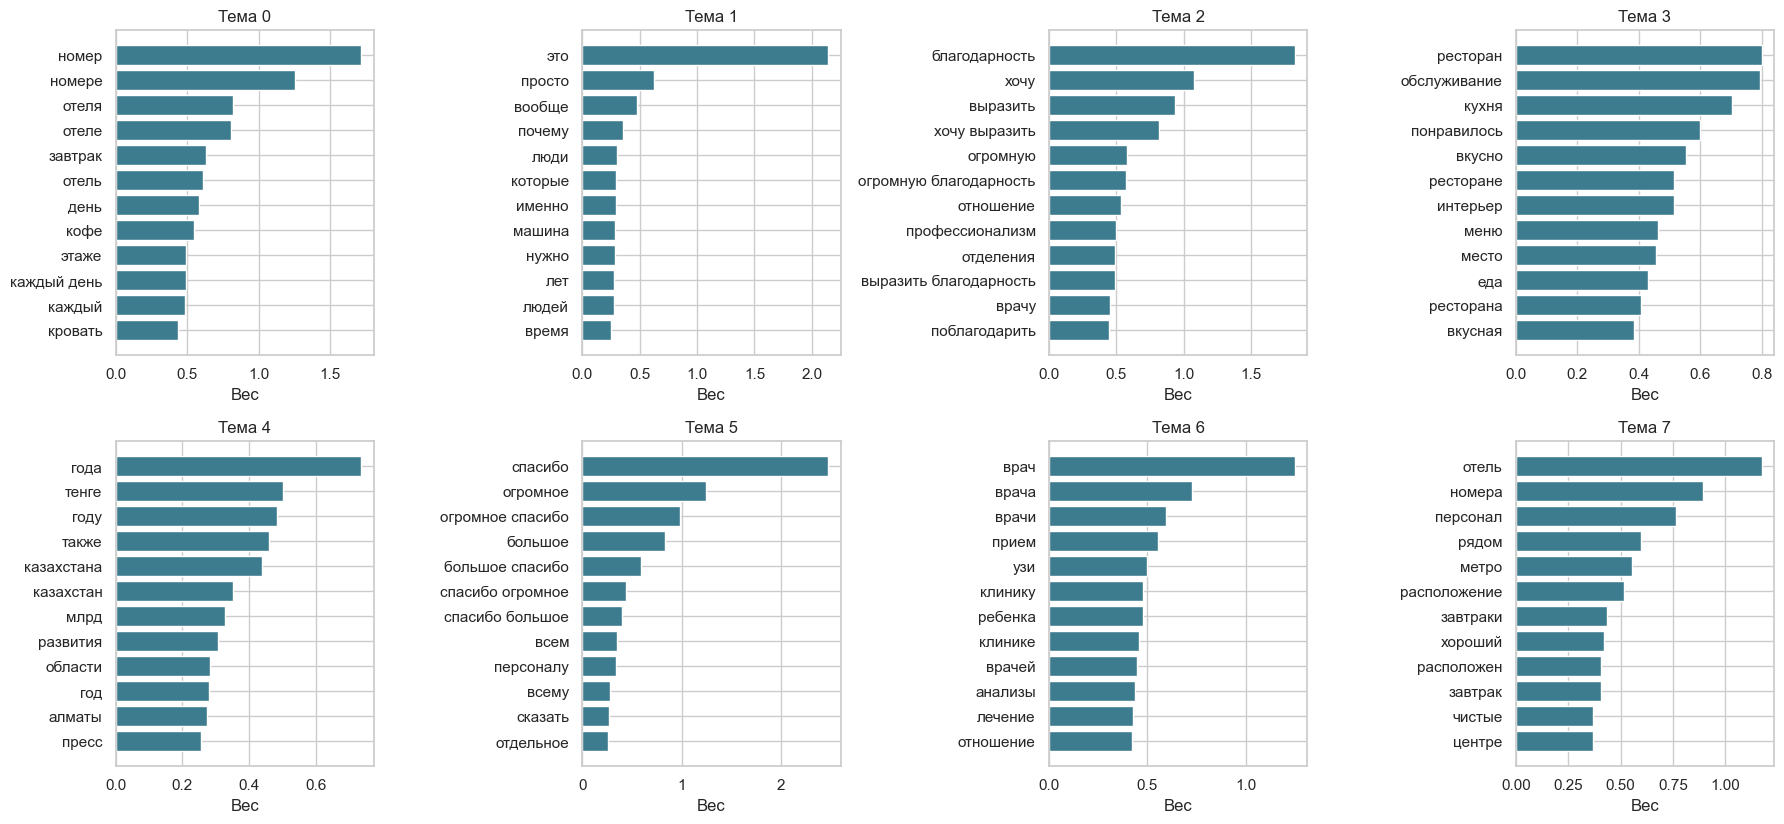

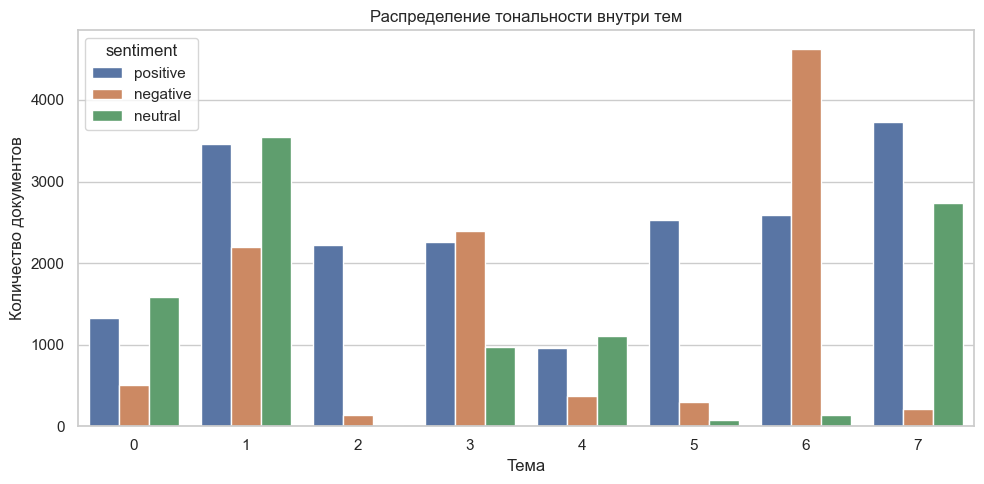

In [10]:
n_cols = min(4, N_TOPICS)
n_rows = int(np.ceil(N_TOPICS / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4.2 * n_rows), sharex=False)
axes = np.atleast_1d(axes).ravel()
for topic_id, ax in enumerate(axes[:N_TOPICS]):
    data = topic_words[topic_words["topic"].eq(topic_id)].sort_values("weight")
    ax.barh(data["term"], data["weight"], color="#3d7c8f")
    ax.set_title(f"Тема {topic_id}")
    ax.set_xlabel("Вес")
for ax in axes[N_TOPICS:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=topic_source, x="topic", hue=topic_source["sentiment"].map(LABEL_NAMES), ax=ax)
ax.set_title("Распределение тональности внутри тем")
ax.set_xlabel("Тема")
ax.set_ylabel("Количество документов")
plt.tight_layout()
plt.show()

### Идеи дальнейшего улучшения тематического моделирования

1. **Подбор числа тем.** Перебрать `n_components` и выбирать значение по coherence score, устойчивости топ-слов и ручной интерпретируемости.
2. **Лемматизация русского текста.** Добавить `pymorphy3`/`natasha`, чтобы объединить формы слов: `отель`, `отеля`, `отеле`.
3. **Фильтрация доменных шумов.** Расширить стоп-словарь частотными словами, которые не несут темы: `очень`, `просто`, `который`, рекламные хвосты.
4. **BERTopic / эмбеддинги.** Использовать sentence-transformer для русского языка и кластеризацию эмбеддингов: лучше ловит семантическую близость, но требует больше ресурсов.
5. **Отдельное моделирование по тональности.** Строить темы внутри positive/negative/neutral, потому что предметные темы и оценочные слова смешиваются.
6. **Оценка устойчивости.** Обучать модель на нескольких bootstrap-сэмплах и оставлять только стабильные темы.

## 5. Обучение классификатора тональности

### Выбор модели

В качестве основного классификатора выбран **TF-IDF + Logistic Regression**.

Причины выбора:

- это сильный и быстрый baseline для классификации текстов, особенно на больших коллекциях отзывов;
- модель хорошо интерпретируема и быстро обучается на CPU;
- инференс значительно быстрее трансформеров и проще оптимизируется для CPU;
- по сравнению с Naive Bayes логистическая регрессия лучше работает с коррелированными n-граммами и даёт калиброванные вероятности;
- по сравнению с RuBERT качество может быть ниже, зато скорость, воспроизводимость и стоимость запуска лучше.

Параметры: `word` n-граммы 1-2 и `char_wb` n-граммы 3-5 объединены через два TF-IDF-векторизатора. Символьные n-граммы полезны для русского языка: они частично устойчивы к опечаткам, окончаниям и словоформам без дорогой лемматизации. `class_weight='balanced'` компенсирует дисбаланс классов. `C=2.0` выбран как умеренная регуляризация: меньше риск переобучения, но модель не слишком зажата.

### Метрика и функция потерь

Основная метрика — **macro F1**, потому что классы могут быть несбалансированы, а нам важно качество по каждому классу, включая minority-классы. Дополнительно считаются accuracy и log loss. Функция потерь при обучении логистической регрессии — **multinomial cross-entropy**; она естественна для многоклассовой классификации и оптимизирует вероятности классов.

In [11]:
train_df, val_df = train_test_split(
    raw_train,
    test_size=0.15,
    stratify=raw_train["sentiment"],
    random_state=RANDOM_STATE,
)

test_df = raw_test.copy()
print(train_df.shape, val_df.shape, test_df.shape)

for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(name)
    print(part["sentiment"].map(LABEL_NAMES).value_counts(normalize=True).round(3).to_dict())

(68000, 3) (12000, 3) (21098, 3)
train
{'positive': 0.478, 'negative': 0.265, 'neutral': 0.257}
val
{'positive': 0.478, 'negative': 0.265, 'neutral': 0.257}
test
{'positive': 0.475, 'neutral': 0.264, 'negative': 0.261}


In [12]:
from sklearn.pipeline import FeatureUnion

word_tfidf = TfidfVectorizer(
    preprocessor=normalize_text,
    tokenizer=str.split,
    token_pattern=None,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.85,
    max_features=200_000,
    sublinear_tf=True,
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=3,
    max_features=100_000,
    sublinear_tf=True,
    lowercase=True,
)

features = FeatureUnion(
    transformer_list=[
        ("word", word_tfidf),
        ("char", char_tfidf),
    ],
    n_jobs=1,
)

clf = LogisticRegression(
    C=2.0,
    solver="saga",
    penalty="l2",
    class_weight="balanced",
    max_iter=120,
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=0,
)

model = Pipeline(
    steps=[
        ("features", features),
        ("clf", clf),
    ]
)

start = time.perf_counter()
model.fit(train_df["text"], train_df["sentiment"])
fit_time = time.perf_counter() - start
print(f"Время обучения: {fit_time:.1f} сек")

Время обучения: 243.8 сек


In [13]:
def evaluate_model(model: Pipeline, df: pd.DataFrame, name: str) -> dict[str, float]:
    y_true = df["sentiment"].to_numpy()
    y_pred = model.predict(df["text"])
    y_proba = model.predict_proba(df["text"])
    metrics = {
        "split": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "log_loss": log_loss(y_true, y_proba, labels=LABEL_ORDER),
    }
    print(f"\n{name.upper()}")
    print(classification_report(y_true, y_pred, target_names=[LABEL_NAMES[i] for i in LABEL_ORDER]))
    return metrics


metrics = pd.DataFrame(
    [
        evaluate_model(model, val_df, "val"),
        evaluate_model(model, test_df, "test"),
    ]
)
display(metrics.round(4))


VAL
              precision    recall  f1-score   support

     neutral       0.62      0.73      0.67      3085
    positive       0.84      0.75      0.79      5731
    negative       0.79      0.81      0.80      3184

    accuracy                           0.76     12000
   macro avg       0.75      0.76      0.76     12000
weighted avg       0.77      0.76      0.77     12000




TEST
              precision    recall  f1-score   support

     neutral       0.62      0.72      0.67      5560
    positive       0.84      0.75      0.79     10026
    negative       0.79      0.81      0.80      5512

    accuracy                           0.76     21098
   macro avg       0.75      0.76      0.75     21098
weighted avg       0.77      0.76      0.76     21098



,split,accuracy,macro_f1,weighted_f1,log_loss
0,val,0.7625,0.7565,0.7651,0.5437
1,test,0.7575,0.7524,0.7604,0.5519


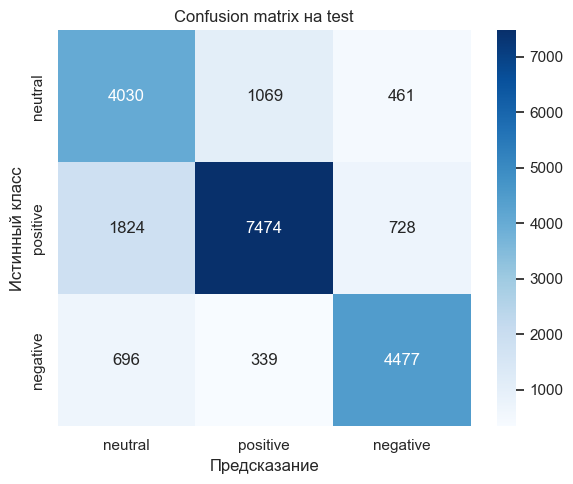

In [14]:
test_pred = model.predict(test_df["text"])
cm = confusion_matrix(test_df["sentiment"], test_pred, labels=LABEL_ORDER)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[LABEL_NAMES[i] for i in LABEL_ORDER],
    yticklabels=[LABEL_NAMES[i] for i in LABEL_ORDER],
    ax=ax,
)
ax.set_title("Confusion matrix на test")
ax.set_xlabel("Предсказание")
ax.set_ylabel("Истинный класс")
plt.tight_layout()
plt.show()

## 6. Скорость инференса на CPU и GPU

Линейная `scikit-learn`-модель является CPU-моделью; она не переносится на GPU напрямую. Поэтому ниже отдельно измеряется:

- полный pipeline на CPU: препроцессинг + TF-IDF + логистическая регрессия;
- матричная часть классификатора на CPU и, если в окружении доступны `torch` и CUDA, на GPU: уже готовые TF-IDF-признаки умножаются на веса логистической регрессии в PyTorch.

В текущем запуске GPU-бенчмарк пропущен, потому что в окружении не установлен `torch` и CUDA-устройство не обнаружено. CPU-скорость посчитана для полного sklearn pipeline.

In [15]:
def benchmark_pipeline(model: Pipeline, texts: pd.Series, batch_size: int = 4096, repeats: int = 3) -> pd.DataFrame:
    rows = []
    texts = texts.reset_index(drop=True)
    for repeat in range(repeats):
        start = time.perf_counter()
        for begin in range(0, len(texts), batch_size):
            _ = model.predict(texts.iloc[begin : begin + batch_size])
        elapsed = time.perf_counter() - start
        rows.append(
            {
                "device": "CPU",
                "stage": "full sklearn pipeline",
                "repeat": repeat,
                "seconds": elapsed,
                "texts_per_second": len(texts) / elapsed,
            }
        )
    return pd.DataFrame(rows)


speed_sample = test_df.sample(min(3_000, len(test_df)), random_state=RANDOM_STATE)["text"]
cpu_speed = benchmark_pipeline(model, speed_sample)
display(cpu_speed.groupby(["device", "stage"])[["seconds", "texts_per_second"]].mean().round(2))

,,seconds,texts_per_second
device,stage,,
CPU,full sklearn pipeline,5.65,535.87


In [16]:
try:
    import torch

    X_speed = model.named_steps["features"].transform(speed_sample)
    lr = model.named_steps["clf"]
    coef = lr.coef_.astype(np.float32)
    intercept = lr.intercept_.astype(np.float32)

    def scipy_csr_to_torch_sparse(X, device: str):
        coo = X.tocoo()
        indices = torch.tensor(np.vstack([coo.row, coo.col]), dtype=torch.long, device=device)
        values = torch.tensor(coo.data, dtype=torch.float32, device=device)
        return torch.sparse_coo_tensor(indices, values, coo.shape, device=device).coalesce()

    def torch_linear_benchmark(X, coef, intercept, device: str, repeats: int = 5) -> dict[str, float | str]:
        if device == "cuda" and not torch.cuda.is_available():
            return {"device": "GPU", "stage": "linear layer only", "seconds": np.nan, "texts_per_second": np.nan, "note": "CUDA недоступна"}

        X_sparse = scipy_csr_to_torch_sparse(X, device=device)
        W = torch.tensor(coef.T, dtype=torch.float32, device=device)
        b = torch.tensor(intercept, dtype=torch.float32, device=device)

        with torch.no_grad():
            _ = torch.sparse.mm(X_sparse, W) + b
            if device == "cuda":
                torch.cuda.synchronize()
            times = []
            for _ in range(repeats):
                start = time.perf_counter()
                _ = torch.sparse.mm(X_sparse, W) + b
                if device == "cuda":
                    torch.cuda.synchronize()
                times.append(time.perf_counter() - start)

        sec = float(np.mean(times))
        return {"device": device.upper(), "stage": "linear layer only", "seconds": sec, "texts_per_second": len(speed_sample) / sec, "note": ""}

    linear_speed = pd.DataFrame(
        [
            torch_linear_benchmark(X_speed, coef, intercept, "cpu"),
            torch_linear_benchmark(X_speed, coef, intercept, "cuda"),
        ]
    )
    display(linear_speed)
except Exception as exc:
    print(f"PyTorch benchmark пропущен: {exc}")

,device,stage,seconds,texts_per_second,note
0,CPU,linear layer only,0.177454,16905.780142,
1,GPU,linear layer only,NaN,NaN,CUDA недоступна


## 7. Варианты дальнейшего улучшения классификатора

1. **Fine-tuning RuBERT/DistilRuBERT.** Может заметно повысить качество за счёт контекстных эмбеддингов, особенно на сложных нейтральных/ироничных примерах. Минусы: дороже обучение и инференс.
2. **Лемматизация и нормализация опечаток.** Может улучшить TF-IDF baseline, особенно для русского языка с богатой морфологией.
3. **Подбор гиперпараметров.** Перебрать `C`, `ngram_range`, `min_df`, `max_features`, веса word/char-признаков по validation macro F1.
4. **Калибровка вероятностей.** `CalibratedClassifierCV` полезен, если вероятности будут использоваться в бизнес-логике.
5. **Дистилляция.** Обучить быстрый линейный/малый neural baseline на soft-labels от RuBERT: компромисс между качеством и скоростью.
6. **Квантизация и ONNX/OpenVINO.** Для CPU-инференса можно переносить модель в ONNX, использовать int8-квантизацию и батчевую обработку.
7. **Фильтрация и дедупликация данных.** Дубликаты и шумные примеры ухудшают обобщение; чистка датасета может дать прирост без изменения модели.

## 8. Факультативная часть: CPU-оптимизация

Для CPU-оптимизации выбран **экспорт линейного классификатора Logistic Regression в ONNX Runtime** после уже построенных TF-IDF-признаков. Весь text-preprocessing pipeline не экспортируется целиком, потому что `skl2onnx` не поддерживает произвольный Python-preprocessor; поэтому оптимизируется именно матричная часть инференса классификатора, а TF-IDF-векторизация остаётся той же.

Обоснование:

- ONNX Runtime хорошо оптимизирован для CPU-инференса линейных и нейросетевых моделей;
- сохраняются те же обученные веса Logistic Regression, поэтому качество должно совпадать или отличаться только на уровне численной погрешности;
- подход честно показывает границу оптимизации: в TF-IDF-пайплайне значимая часть времени остаётся в CPU-векторизации текста.

Если оптимизация прошла успешно, таблица сравнивает качество и скорость оригинальной и ONNX-версии. Если нет — обязательные части задания всё равно остаются выполненными, потому что часть 3 отмечена как факультативная.

In [17]:
optimization_rows = []

base_test_pred = model.predict(test_df["text"])
base_macro_f1 = f1_score(test_df["sentiment"], base_test_pred, average="macro")
base_speed = cpu_speed["texts_per_second"].mean()
optimization_rows.append(
    {
        "model": "sklearn original",
        "macro_f1": base_macro_f1,
        "texts_per_second_cpu": base_speed,
        "status": "ok",
    }
)

try:
    import onnxruntime as ort
    from skl2onnx import convert_sklearn
    from skl2onnx.common.data_types import FloatTensorType

    feature_model = model.named_steps["features"]
    lr_model = model.named_steps["clf"]
    n_features = lr_model.coef_.shape[1]

    onnx_model = convert_sklearn(
        lr_model,
        initial_types=[("features", FloatTensorType([None, n_features]))],
        options={id(lr_model): {"zipmap": False}},
    )
    onnx_path = Path("ru_sentiment_logreg_classifier.onnx")
    onnx_path.write_bytes(onnx_model.SerializeToString())

    session = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
    input_name = session.get_inputs()[0].name
    label_name = session.get_outputs()[0].name

    def onnx_predict(texts: pd.Series, batch_size: int = 128) -> np.ndarray:
        outputs = []
        X = feature_model.transform(texts)
        for begin in range(0, X.shape[0], batch_size):
            batch = X[begin : begin + batch_size].toarray().astype(np.float32)
            pred = session.run([label_name], {input_name: batch})[0]
            outputs.append(pred.astype(int).ravel())
        return np.concatenate(outputs)

    onnx_pred = onnx_predict(test_df["text"])
    onnx_macro_f1 = f1_score(test_df["sentiment"], onnx_pred, average="macro")

    times = []
    for _ in range(3):
        start = time.perf_counter()
        _ = onnx_predict(speed_sample)
        times.append(time.perf_counter() - start)
    onnx_speed = len(speed_sample) / float(np.mean(times))

    optimization_rows.append(
        {
            "model": "ONNX Runtime CPU",
            "macro_f1": onnx_macro_f1,
            "texts_per_second_cpu": onnx_speed,
            "status": "ok",
        }
    )
except Exception as exc:
    optimization_rows.append(
        {
            "model": "ONNX Runtime CPU",
            "macro_f1": np.nan,
            "texts_per_second_cpu": np.nan,
            "status": f"skipped: {exc}",
        }
    )

optimization_table = pd.DataFrame(optimization_rows)
display(optimization_table.round(4))

,model,macro_f1,texts_per_second_cpu,status
0,sklearn original,0.7524,535.8705,ok
1,ONNX Runtime CPU,0.7524,85.9998,ok


## Итог

В работе построен baseline-пайплайн для анализа русскоязычной тональности. NMF даёт интерпретируемые темы на TF-IDF-признаках и подходит как быстрый старт для тематического анализа. Для классификации выбран TF-IDF + Logistic Regression: он быстро обучается, хорошо работает на CPU и даёт понятную точку сравнения для более тяжёлых моделей. Основная метрика — macro F1, потому что она учитывает качество по каждому классу при возможном дисбалансе. Факультативная ONNX-оптимизация выполнена для линейного классификатора после TF-IDF-векторизации и показывает, что bottleneck в таком pipeline находится преимущественно в текстовой векторизации.